# Exploratory Data Analysis — Engineering Courses Dataset

## Objective

This notebook performs exploratory data analysis (EDA) on the engineering course dataset to understand:

- Dataset structure and data quality
- Course distribution across engineering branches and tracks
- Difficulty levels and learning formats
- Course providers
- Skills and tools taught
- Career paths and industry sectors
- Course ratings, reviews, duration, and other numerical attributes
- Prerequisite relationships
- Patterns useful for building an AI-powered personalized learning path recommender

The findings from this analysis will guide the feature engineering and recommendation-engine design.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

df = pd.read_csv("engineering_courses_dataset.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 2,400 rows × 16 columns


,course_id,branch,track,course_title,difficulty_level,provider,format,description,skills_taught,tools_covered,prerequisite_course_title,estimated_hours,rating,num_reviews,career_paths,industry_sectors
0,BME-0145,Biomedical Engineering,Genomics and Proteomics Basics,Applied Genomics and Proteomics Basics,Intermediate,Pluralsight,Instructor-led Live,"Building on foundational knowledge, this course goes deeper into Genomics and Proteomics Basics, covering applied te...",matlab; medical device design; regulatory compliance; biomechanics analysis,python; ansys; solidworks,Introduction to Genomics and Proteomics Basics,39,3.8,683,rehabilitation engineer; regulatory affairs specialist; clinical engineer,medical devices; healthcare
1,IPE-0074,Industrial and Production Engineering,Six Sigma,Applied Six Sigma,Intermediate,NPTEL,Video Course,"Building on foundational knowledge, this course goes deeper into Six Sigma, covering applied techniques, common indu...",supply chain analysis; erp systems; simulation modeling; operations research,minitab; sap; ms project,Introduction to Six Sigma,20,4.0,1952,industrial engineer; quality engineer; process improvement engineer,automotive; manufacturing
2,CSE-0152,Computer Science Engineering,VLSI Design,Introduction to VLSI Design,Beginner,Udacity,Video Course,This foundational course introduces the core concepts of VLSI Design within Computer Science Engineering. Learners b...,c++; system design; linux; git,jenkins; mongodb; gcp,NaN,13,4.2,2334,ml engineer; backend developer; data scientist,finance; telecommunications
3,ECE-0030,Electronics & Communication Engineering,Signal Processing,Signal Processing Capstone Project,Capstone,FutureLearn,Instructor-led Live,A project-based capstone course where learners apply everything covered across the Signal Processing track to design...,signal processing; vhdl; circuit design; pcb design,raspberry pi; cadence; keil,Advanced Signal Processing,17,3.8,2841,embedded systems engineer; vlsi design engineer; communication systems engineer,automotive; defense
4,CHE-0078,Chemical Engineering,Petrochemical Engineering,Advanced Petrochemical Engineering,Advanced,edX,Video Course,"This advanced course covers complex, industry-relevant topics in Petrochemical Engineering, including optimization t...",reactor design; mass balance; process simulation; heat balance,aspen plus; hysys; comsol,Applied Petrochemical Engineering,45,4.7,4418,chemical process consultant; refinery engineer; process engineer,manufacturing; petrochemical


## 1. Dataset Overview

In [2]:
print("Shape:", df.shape)
print("\nColumn names:")
for col in df.columns:
    print("-", col)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 5 records:")
display(df.head())


Shape: (2400, 16)

Column names:
- course_id
- branch
- track
- course_title
- difficulty_level
- provider
- format
- description
- skills_taught
- tools_covered
- prerequisite_course_title
- estimated_hours
- rating
- num_reviews
- career_paths
- industry_sectors

Data types:


,dtype
course_id,object
branch,object
track,object
course_title,object
difficulty_level,object
provider,object
format,object
description,object
skills_taught,object
tools_covered,object



First 5 records:


,course_id,branch,track,course_title,difficulty_level,provider,format,description,skills_taught,tools_covered,prerequisite_course_title,estimated_hours,rating,num_reviews,career_paths,industry_sectors
0,BME-0145,Biomedical Engineering,Genomics and Proteomics Basics,Applied Genomics and Proteomics Basics,Intermediate,Pluralsight,Instructor-led Live,"Building on foundational knowledge, this course goes deeper into Genomics and Proteomics Basics, covering applied te...",matlab; medical device design; regulatory compliance; biomechanics analysis,python; ansys; solidworks,Introduction to Genomics and Proteomics Basics,39,3.8,683,rehabilitation engineer; regulatory affairs specialist; clinical engineer,medical devices; healthcare
1,IPE-0074,Industrial and Production Engineering,Six Sigma,Applied Six Sigma,Intermediate,NPTEL,Video Course,"Building on foundational knowledge, this course goes deeper into Six Sigma, covering applied techniques, common indu...",supply chain analysis; erp systems; simulation modeling; operations research,minitab; sap; ms project,Introduction to Six Sigma,20,4.0,1952,industrial engineer; quality engineer; process improvement engineer,automotive; manufacturing
2,CSE-0152,Computer Science Engineering,VLSI Design,Introduction to VLSI Design,Beginner,Udacity,Video Course,This foundational course introduces the core concepts of VLSI Design within Computer Science Engineering. Learners b...,c++; system design; linux; git,jenkins; mongodb; gcp,NaN,13,4.2,2334,ml engineer; backend developer; data scientist,finance; telecommunications
3,ECE-0030,Electronics & Communication Engineering,Signal Processing,Signal Processing Capstone Project,Capstone,FutureLearn,Instructor-led Live,A project-based capstone course where learners apply everything covered across the Signal Processing track to design...,signal processing; vhdl; circuit design; pcb design,raspberry pi; cadence; keil,Advanced Signal Processing,17,3.8,2841,embedded systems engineer; vlsi design engineer; communication systems engineer,automotive; defense
4,CHE-0078,Chemical Engineering,Petrochemical Engineering,Advanced Petrochemical Engineering,Advanced,edX,Video Course,"This advanced course covers complex, industry-relevant topics in Petrochemical Engineering, including optimization t...",reactor design; mass balance; process simulation; heat balance,aspen plus; hysys; comsol,Applied Petrochemical Engineering,45,4.7,4418,chemical process consultant; refinery engineer; process engineer,manufacturing; petrochemical


## 2. Data Quality Check

In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values("missing_count", ascending=False)

display(quality)

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate course IDs:", df["course_id"].duplicated().sum() if "course_id" in df.columns else "course_id column not found")


,dtype,missing_count,missing_percent,unique_values
prerequisite_course_title,object,720,30.0,705
course_id,object,0,0.0,2400
branch,object,0,0.0,12
track,object,0,0.0,235
course_title,object,0,0.0,940
difficulty_level,object,0,0.0,4
provider,object,0,0.0,8
format,object,0,0.0,5
description,object,0,0.0,950
skills_taught,object,0,0.0,1796


Duplicate rows: 0
Duplicate course IDs: 0


## 3. Descriptive Statistics

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns
if len(numeric_cols):
    display(df[numeric_cols].describe().T)
else:
    print("No numeric columns found.")


,count,mean,std,min,25%,50%,75%,max
estimated_hours,2400.0,28.543333,12.539882,10.0,18.00,28.0,38.00,55.0
rating,2400.0,4.300333,0.402265,3.6,4.00,4.3,4.60,5.0
num_reviews,2400.0,3015.042500,1703.259802,82.0,1504.75,3040.5,4484.25,6000.0


## 4. Categorical Distributions

In [5]:
print("### branch")
display(df["branch"].value_counts(dropna=False).to_frame("count"))


### branch


,count
branch,
Biomedical Engineering,200
Industrial and Production Engineering,200
Computer Science Engineering,200
Electronics & Communication Engineering,200
Chemical Engineering,200
Civil Engineering,200
Electrical Engineering,200
Petroleum Engineering,200
Environmental Engineering,200


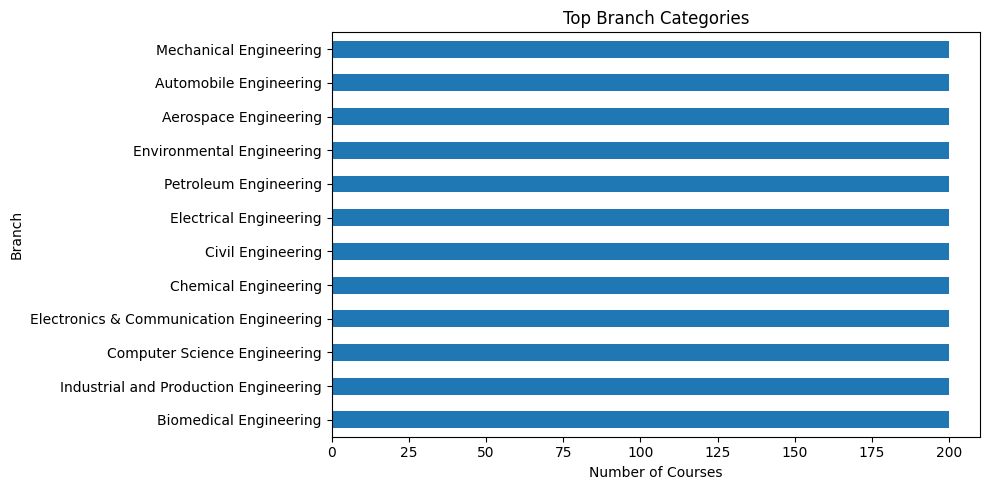

In [6]:
counts = df["branch"].value_counts().head(15)

plt.figure(figsize=(10, 5))
counts.sort_values().plot(kind="barh")
plt.title("Top Branch Categories")
plt.xlabel("Number of Courses")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()


In [7]:
print("### track")
display(df["track"].value_counts(dropna=False).to_frame("count"))


### track


,count
track,
Automotive Systems,20
Electric Vehicle Technology,20
Signal Processing,20
Industrial Automation,20
Renewable Energy Systems,20
...,...
Catalysis Engineering,10
Database Systems,10
Reservoir Engineering,10


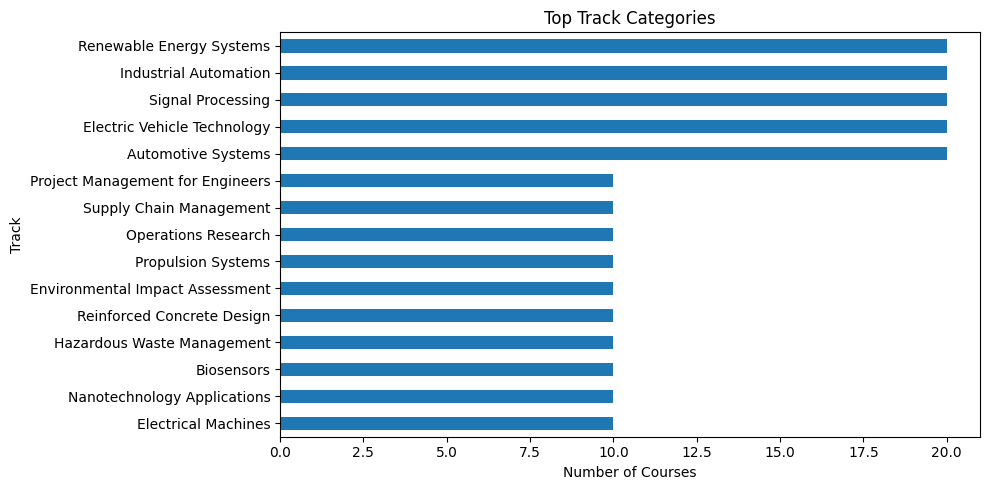

In [8]:
counts = df["track"].value_counts().head(15)

plt.figure(figsize=(10, 5))
counts.sort_values().plot(kind="barh")
plt.title("Top Track Categories")
plt.xlabel("Number of Courses")
plt.ylabel("Track")
plt.tight_layout()
plt.show()


In [9]:
print("### difficulty_level")
display(df["difficulty_level"].value_counts(dropna=False).to_frame("count"))


### difficulty_level


,count
difficulty_level,
Intermediate,720
Beginner,720
Advanced,720
Capstone,240


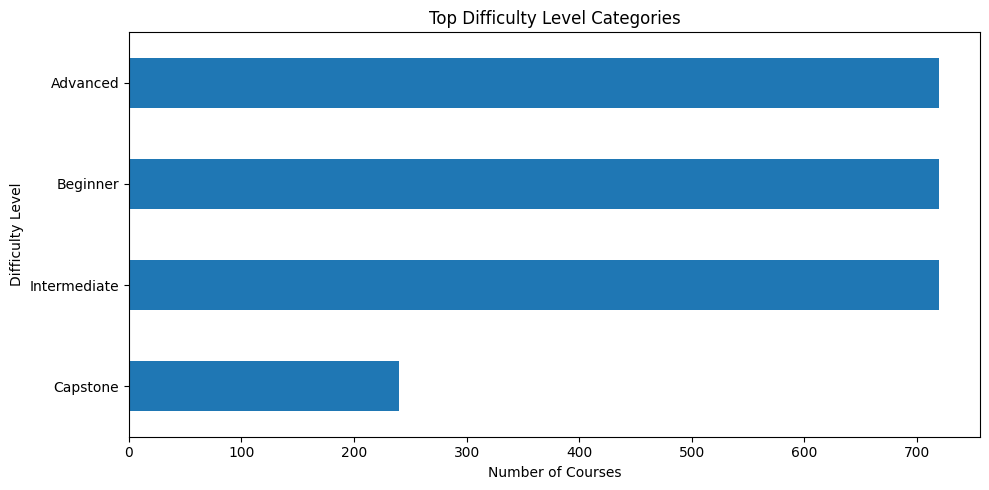

In [10]:
counts = df["difficulty_level"].value_counts().head(15)

plt.figure(figsize=(10, 5))
counts.sort_values().plot(kind="barh")
plt.title("Top Difficulty Level Categories")
plt.xlabel("Number of Courses")
plt.ylabel("Difficulty Level")
plt.tight_layout()
plt.show()


In [11]:
print("### provider")
display(df["provider"].value_counts(dropna=False).to_frame("count"))


### provider


,count
provider,
FutureLearn,314
NPTEL,311
edX,310
Coursera,308
Udacity,297
Pluralsight,295
Udemy,285
LinkedIn Learning,280


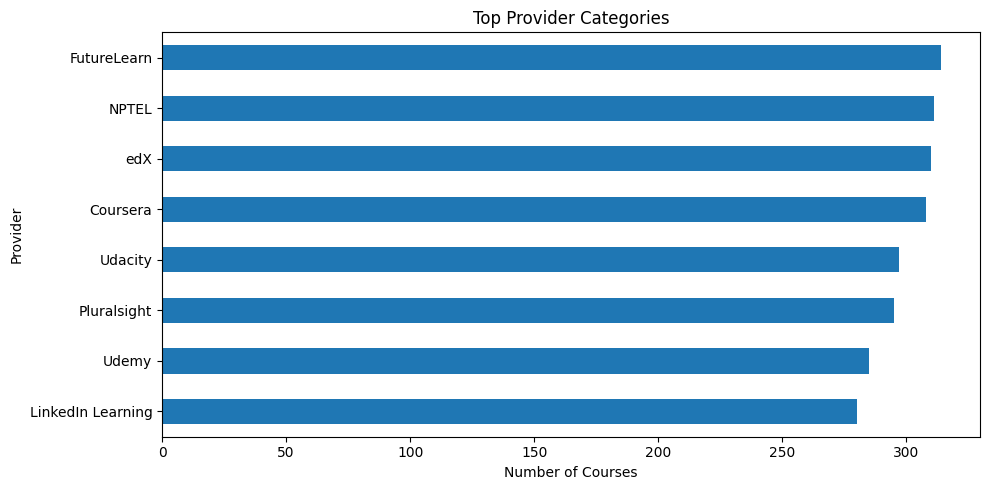

In [12]:
counts = df["provider"].value_counts().head(15)

plt.figure(figsize=(10, 5))
counts.sort_values().plot(kind="barh")
plt.title("Top Provider Categories")
plt.xlabel("Number of Courses")
plt.ylabel("Provider")
plt.tight_layout()
plt.show()


In [13]:
print("### format")
display(df["format"].value_counts(dropna=False).to_frame("count"))


### format


,count
format,
Interactive Lab,507
Instructor-led Live,491
Video Course,473
Blended (Video + Project),468
Self-paced Reading,461


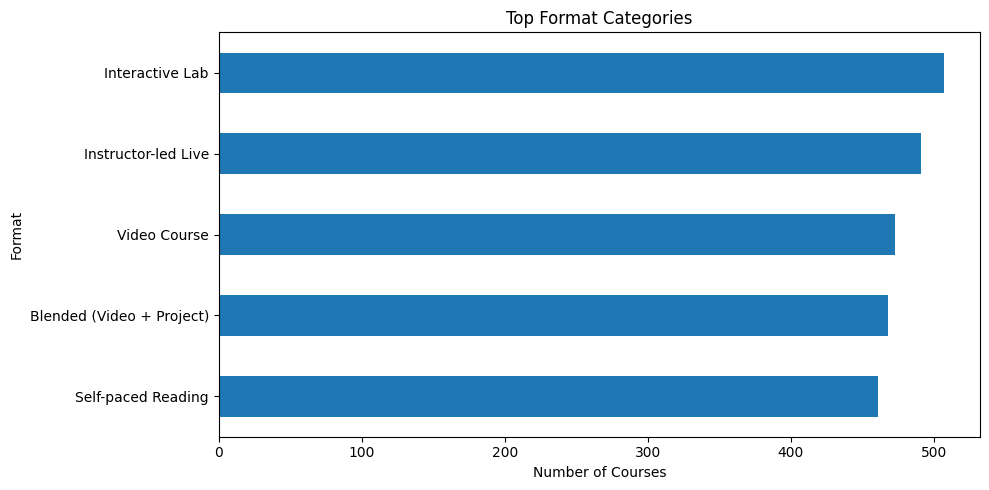

In [14]:
counts = df["format"].value_counts().head(15)

plt.figure(figsize=(10, 5))
counts.sort_values().plot(kind="barh")
plt.title("Top Format Categories")
plt.xlabel("Number of Courses")
plt.ylabel("Format")
plt.tight_layout()
plt.show()


## 5. Course Duration and Ratings

In [ ]:
analysis_cols = [c for c in ["estimated_hours", "rating", "num_reviews"] if c in df.columns]

if analysis_cols:
    display(df[analysis_cols].describe().T)

    for col in analysis_cols:
        plt.figure(figsize=(9, 5))
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f"Distribution of {col.replace('_', ' ').title()}")
        plt.xlabel(col.replace("_", " ").title())
        plt.ylabel("Number of Courses")
        plt.tight_layout()
        plt.show()


## 6. Rating vs. Number of Reviews

In [ ]:
if {"rating", "num_reviews"}.issubset(df.columns):
    plt.figure(figsize=(9, 6))
    plt.scatter(df["num_reviews"], df["rating"], alpha=0.5)
    plt.xscale("log")
    plt.xlabel("Number of Reviews (log scale)")
    plt.ylabel("Rating")
    plt.title("Course Rating vs. Number of Reviews")
    plt.tight_layout()
    plt.show()

    print("Correlation:")
    display(df[["rating", "num_reviews"]].corr())


## 7. Skills and Tools Coverage

In [ ]:
def split_items(value):
    if pd.isna(value):
        return []
    return [x.strip() for x in str(value).replace("|", ";").split(";") if x.strip()]

def frequency_from_column(series):
    values = []
    for value in series.dropna():
        values.extend(split_items(value))
    return pd.Series(values).value_counts()

if "skills_taught" in df.columns:
    skill_counts = frequency_from_column(df["skills_taught"])
    print("Top skills:")
    display(skill_counts.head(25).to_frame("course_count"))

    plt.figure(figsize=(10, 7))
    skill_counts.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 Skills Taught")
    plt.xlabel("Number of Courses")
    plt.tight_layout()
    plt.show()

if "tools_covered" in df.columns:
    tool_counts = frequency_from_column(df["tools_covered"])
    print("Top tools:")
    display(tool_counts.head(25).to_frame("course_count"))

    plt.figure(figsize=(10, 7))
    tool_counts.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 Tools Covered")
    plt.xlabel("Number of Courses")
    plt.tight_layout()
    plt.show()


## 8. Career Paths and Industry Sectors

In [ ]:
if "career_paths" in df.columns:
    career_counts = frequency_from_column(df["career_paths"])
    print("Top career paths:")
    display(career_counts.head(25).to_frame("course_count"))

    plt.figure(figsize=(10, 7))
    career_counts.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 Career Paths")
    plt.xlabel("Number of Courses")
    plt.tight_layout()
    plt.show()

if "industry_sectors" in df.columns:
    industry_counts = frequency_from_column(df["industry_sectors"])
    print("Top industry sectors:")
    display(industry_counts.head(25).to_frame("course_count"))

    plt.figure(figsize=(10, 7))
    industry_counts.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 Industry Sectors")
    plt.xlabel("Number of Courses")
    plt.tight_layout()
    plt.show()


## 9. Difficulty vs. Course Duration

In [ ]:
if {"difficulty_level", "estimated_hours"}.issubset(df.columns):
    difficulty_order = ["Beginner", "Intermediate", "Advanced", "Capstone"]
    available_order = [x for x in difficulty_order if x in df["difficulty_level"].dropna().unique()]

    grouped = df.groupby("difficulty_level")["estimated_hours"].agg(["count", "mean", "median", "min", "max"])
    if available_order:
        grouped = grouped.reindex(available_order)
    display(grouped)

    plt.figure(figsize=(10, 6))
    data = [
        df.loc[df["difficulty_level"] == level, "estimated_hours"].dropna()
        for level in available_order
    ]
    if data:
        plt.boxplot(data, labels=available_order)
        plt.title("Estimated Hours by Difficulty Level")
        plt.xlabel("Difficulty Level")
        plt.ylabel("Estimated Hours")
        plt.tight_layout()
        plt.show()


## 10. Prerequisite Analysis

In [ ]:
if "prerequisite_course_title" in df.columns:
    prereq = df["prerequisite_course_title"].fillna("").astype(str).str.strip()
    no_prereq = prereq.eq("") | prereq.str.lower().isin(["none", "nan", "no prerequisite", "no prerequisites"])

    print(f"Courses with prerequisites: {(~no_prereq).sum():,}")
    print(f"Courses without prerequisites: {no_prereq.sum():,}")

    prereq_counts = prereq[~no_prereq].value_counts()
    print("\nMost frequently referenced prerequisites:")
    display(prereq_counts.head(20).to_frame("referenced_count"))


## 11. Branch × Difficulty Analysis

In [ ]:
if {"branch", "difficulty_level"}.issubset(df.columns):
    cross_tab = pd.crosstab(df["branch"], df["difficulty_level"])
    display(cross_tab)

    cross_tab.plot(kind="bar", figsize=(12, 6))
    plt.title("Difficulty Distribution Across Engineering Branches")
    plt.xlabel("Engineering Branch")
    plt.ylabel("Number of Courses")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 12. Track × Difficulty Analysis

In [ ]:
if {"track", "difficulty_level"}.issubset(df.columns):
    track_counts = df["track"].value_counts()
    top_tracks = track_counts.head(15).index

    cross_tab = pd.crosstab(
        df.loc[df["track"].isin(top_tracks), "track"],
        df.loc[df["track"].isin(top_tracks), "difficulty_level"]
    )

    display(cross_tab)

    cross_tab.plot(kind="bar", figsize=(12, 6))
    plt.title("Difficulty Distribution for Top Learning Tracks")
    plt.xlabel("Track")
    plt.ylabel("Number of Courses")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 13. Correlation Analysis

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(9, 7))
    plt.imshow(corr, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Numerical Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()

    display(corr)


## 14. EDA Findings for the Recommendation System

In [ ]:
print("Dataset:", f"{len(df):,} courses")
print("Features:", len(df.columns))

if "branch" in df.columns:
    print("Branches:", df["branch"].nunique())
if "track" in df.columns:
    print("Tracks:", df["track"].nunique())
if "provider" in df.columns:
    print("Providers:", df["provider"].nunique())
if "difficulty_level" in df.columns:
    print("Difficulty levels:", df["difficulty_level"].nunique())

print("\nPotential recommendation signals available:")
signals = [
    "course description",
    "skills taught",
    "tools covered",
    "career paths",
    "industry sectors",
    "difficulty level",
    "prerequisite course",
    "estimated hours",
    "rating",
    "number of reviews",
    "branch",
    "track",
    "format"
]
for s in signals:
    print("✓", s)


## Key Conclusions

The EDA establishes that the dataset contains the main information required for a content-based and hybrid personalized learning recommender.

### Most useful recommendation features

1. **`description` + `skills_taught`** — suitable for semantic embedding and similarity-based recommendations.
2. **`career_paths`** — enables goal-to-course matching.
3. **`industry_sectors`** — enables industry-specific personalization.
4. **`prerequisite_course_title`** — supports prerequisite-aware learning-path generation.
5. **`difficulty_level`** — helps avoid recommending courses above or below the learner's level.
6. **`estimated_hours`** — allows recommendations to respect the learner's available study time.
7. **`rating` and `num_reviews`** — useful as course-quality signals.
8. **`branch` and `track`** — useful for domain-specific personalization.

### Next ML stage

The next notebook/module should transform these findings into a recommendation pipeline:

**Course metadata → text preprocessing → embeddings → semantic similarity → skill-gap matching → hybrid ranking → prerequisite-aware learning path.**
